## Task 4 - Training Data Preparation and Training for Blurry Object Detection

In this script, we want to train a YOLO model with the deblur image. We take the metrics and compare it with the vanilla model

In [29]:
# Importing necessary libraries
import os
import cv2                          # OpenCV: image loading, drawing bounding boxes
import numpy as np
import matplotlib.pyplot as plt     # For displaying results side by side
%matplotlib inline
import matplotlib.patches as mpatches
import seaborn as sns
from ultralytics import YOLO        # The YOLO11 model interface
from pathlib import Path
import glob
import pandas as pd
import time
import shutil
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # give comment for this row

In [10]:
# define the global variable
base_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
main_deblur_path = os.path.join(base_dir, "..", "data", "train_test_split" , "deblur_richardson_lucy")
main_blur_path = os.path.join(base_dir, "..", "data", "train_test_split" , "blur")
main_sharp_path = os.path.join(base_dir, "..", "data", "train_test_split" , "sharp")

BLUR_PATH = os.path.join(base_dir, "..", "data", "blur", "images")

SHARP_PATH = os.path.join(base_dir, "..", "data", "sharp", "images")
BLUR_OBJ_DET_PATH = os.path.join(base_dir, "..", "data", "task3_outputs", "blur")
DEBLUR_OBJ_DET_PATH = os.path.join(base_dir, "..", "data", "task3_outputs", "deblur_richardson_lucy")
SHARP_OBJ_DET_PATH = os.path.join(base_dir, "..", "data", "task3_outputs", "sharp")
os.makedirs(BLUR_OBJ_DET_PATH, exist_ok=True)
os.makedirs(DEBLUR_OBJ_DET_PATH, exist_ok=True)
os.makedirs(SHARP_OBJ_DET_PATH, exist_ok=True)

In [3]:
training_model = YOLO('yolo11m.pt')

In [49]:
data_yaml_path = os.path.join(main_deblur_path, 'deblur.yaml') # change this accordingly
data_yaml_path

'd:\\MSC AIML - Adelaide\\!-COURSES-!\\7- COMPUTER VISION AND MULTIMODAL ML\\Assignment\\Assignment 1\\notebooks\\..\\data\\train_test_split\\deblur_richardson_lucy\\deblur.yaml'

In [6]:
main_deblur_path

'd:\\MSC AIML - Adelaide\\!-COURSES-!\\7- COMPUTER VISION AND MULTIMODAL ML\\Assignment\\Assignment 1\\notebooks\\..\\data\\train_test_split\\deblur_richardson_lucy'

In [6]:
start_time = time.perf_counter()

results = training_model.train(data=data_yaml_path, epochs=100, imgsz=320, batch=16, optimizer='AdamW', patience=50, project='YOLO_Deblur_Training_3', name='deblur_run_1', lr0=0.001)

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")

Ultralytics 8.4.21  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\deblur_richardson_lucy\deblur2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, mo

In [ ]:
# now we have the trained model. we will use it on the test dataset of blur, deblur_richardson_lucy, and sharp.

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_

In [17]:
print(main_deblur_path)
print(main_blur_path)
print(main_sharp_path)

d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\deblur_richardson_lucy
d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\blur
d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\sharp


Now, we use YOLO training model to predict and evaluate on the blur, deblur_richardson_lucy, and sharp dataset to get the result

In [15]:
# make a function to run predictions on all images in a folder. The result is the metrics from prediction function

def run_yolo_on_test_images(model_instance, test_base_path, conf_threshold=0.25, iou_threshold=0.45):
    """
    """
    test_images_dir = Path(os.path.join(test_base_path, 'test', 'images'))
    print(test_images_dir)
    
    if not test_images_dir.exists():
        print(f"Error: Test images directory not found at {test_images_dir}")
        return {}

    image_paths = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.jpeg")) + \
                  list(test_images_dir.glob("*.png"))

    if not image_paths:
        print(f"No images found in {test_images_dir}")
        return {}

    all_predictions = {}
    print(f"Running YOLO prediction on {len(image_paths)} test images...")

    for img_path in image_paths:
        try:
            results = model_instance.predict(source=str(img_path), conf=conf_threshold, iou=iou_threshold, verbose=False)
            all_predictions[img_path.name] = results
        except Exception as e:
            print(f"Error predicting on {img_path.name}: {e}")
            continue
            
    print("YOLO prediction complete for all test images.")
    return all_predictions

In [18]:
# run the yolo training predictions on blur test image

start_time = time.perf_counter() # for timing
blur_test_predictions = run_yolo_on_test_images(training_model, main_blur_path, conf_threshold=0.25, iou_threshold=0.45) # run the yolo predictions on blur test image

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")


d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\blur\test\images
Running YOLO prediction on 750 test images...
YOLO prediction complete for all test images.
Total execution time: 0.90 minutes.
Total execution time: 54.00 seconds.


In [19]:
# now, we want to calculate the average of confidence from the blur test images. We will do it too for deblur_richardhson_lucy and sharp image, and we will visualise it.
blur_all_confidences = []
for image_name, result in blur_test_predictions.items():
    if result: # check if the result is exists
        result_object = result[0]

        if hasattr(result_object,'boxes') and hasattr(result_object.boxes, 'conf') and len(result_object.boxes.conf) > 0: #
            blur_all_confidences.extend(result_object.boxes.conf.tolist())

# get the mean, median, and std dev, for further analysis
blur_mean_confidences = np.mean(blur_all_confidences)
blur_median_confidences = np.median(blur_all_confidences)
blur_std_confidences = np.std(blur_all_confidences)

print(f"The mean is: {blur_mean_confidences}. The median is: {blur_median_confidences}. The standard deviation is: {blur_std_confidences}")


The mean is: 0.5905472328257425. The median is: 0.5837592482566833. The standard deviation is: 0.22255903222092058


In [ ]:
# run the yolo predictions on deblur test image

start_time = time.perf_counter() # for timing
deblur_test_predictions = run_yolo_on_test_images(training_model, main_deblur_path, conf_threshold=0.25, iou_threshold=0.45) # run the yolo predictions on deblur test image

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")

d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\deblur_richardson_lucy\test\images
Running YOLO prediction on 750 test images...
YOLO prediction complete for all test images.
Total execution time: 0.67 minutes.
Total execution time: 40.00 seconds.


In [ ]:
# now, we want to calculate the average of confidence from the deblur test images. We will do it too for deblur_richardhson_lucy and sharp image, and we will visualise it.
deblur_all_confidences = []
for image_name, result in deblur_test_predictions.items():
    if result: # check if the result is exists
        result_object = result[0]

        if hasattr(result_object,'boxes') and hasattr(result_object.boxes, 'conf') and len(result_object.boxes.conf) > 0: #
            deblur_all_confidences.extend(result_object.boxes.conf.tolist())

# get the mean, median, and std dev, for further analysis
deblur_mean_confidences = np.mean(deblur_all_confidences)
deblur_median_confidences = np.median(deblur_all_confidences)
deblur_std_confidences = np.std(deblur_all_confidences)

print(f"The mean is: {deblur_mean_confidences}. The median is: {deblur_median_confidences}. The standard deviation is: {deblur_std_confidences}")

The mean is: 0.5910751694723513. The median is: 0.5938284993171692. The standard deviation is: 0.22237672209342565


In [22]:
# run the yolo predictions on sharp sharp image

start_time = time.perf_counter() # for timing
sharp_test_predictions = run_yolo_on_test_images(training_model, main_sharp_path, conf_threshold=0.25, iou_threshold=0.45) # run the yolo predictions on sharp test image

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")

d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\sharp\test\images
Running YOLO prediction on 750 test images...
YOLO prediction complete for all test images.
Total execution time: 0.71 minutes.
Total execution time: 42.51 seconds.


In [23]:
# now, we want to calculate the average of confidence from the sharp test images. We will do it too for deblur_richardhson_lucy and sharp image, and we will visualise it.
sharp_all_confidences = []
for image_name, result in sharp_test_predictions.items():
    if result: # check if the result is exists
        result_object = result[0]

        if hasattr(result_object,'boxes') and hasattr(result_object.boxes, 'conf') and len(result_object.boxes.conf) > 0: #
            sharp_all_confidences.extend(result_object.boxes.conf.tolist())

# get the mean, median, and std dev, for further analysis
sharp_mean_confidences = np.mean(sharp_all_confidences)
sharp_median_confidences = np.median(sharp_all_confidences)
sharp_std_confidences = np.std(sharp_all_confidences)

print(f"The mean is: {sharp_mean_confidences}. The median is: {sharp_median_confidences}. The standard deviation is: {sharp_std_confidences}")

The mean is: 0.5777232240698191. The median is: 0.5608136653900146. The standard deviation is: 0.2219993444584591


In [24]:
# combine all mean, median, and std dev, and make visualisation
mean_combined = [blur_mean_confidences, deblur_mean_confidences, sharp_mean_confidences]
median_combined = [blur_median_confidences, deblur_median_confidences, sharp_median_confidences]
std_dev_combined = [blur_std_confidences, deblur_std_confidences, sharp_std_confidences]

In [25]:
data_confidence = {
    'Image Type': ['Blur', 'Deblur', 'Sharp', 'Blur', 'Deblur', 'Sharp', 'Blur', 'Deblur', 'Sharp'],
    'Metric Type': ['Mean Confidence'] * 3 + ['Median Confidence'] * 3 + ['Std Dev Confidence'] * 3,
    'Value': mean_combined + median_combined + std_dev_combined
}
df_metrics = pd.DataFrame(data_confidence)
df_metrics

,Image Type,Metric Type,Value
0,Blur,Mean Confidence,0.590547
1,Deblur,Mean Confidence,0.591075
2,Sharp,Mean Confidence,0.577723
3,Blur,Median Confidence,0.583759
4,Deblur,Median Confidence,0.593828
5,Sharp,Median Confidence,0.560814
6,Blur,Std Dev Confidence,0.222559
7,Deblur,Std Dev Confidence,0.222377
8,Sharp,Std Dev Confidence,0.221999


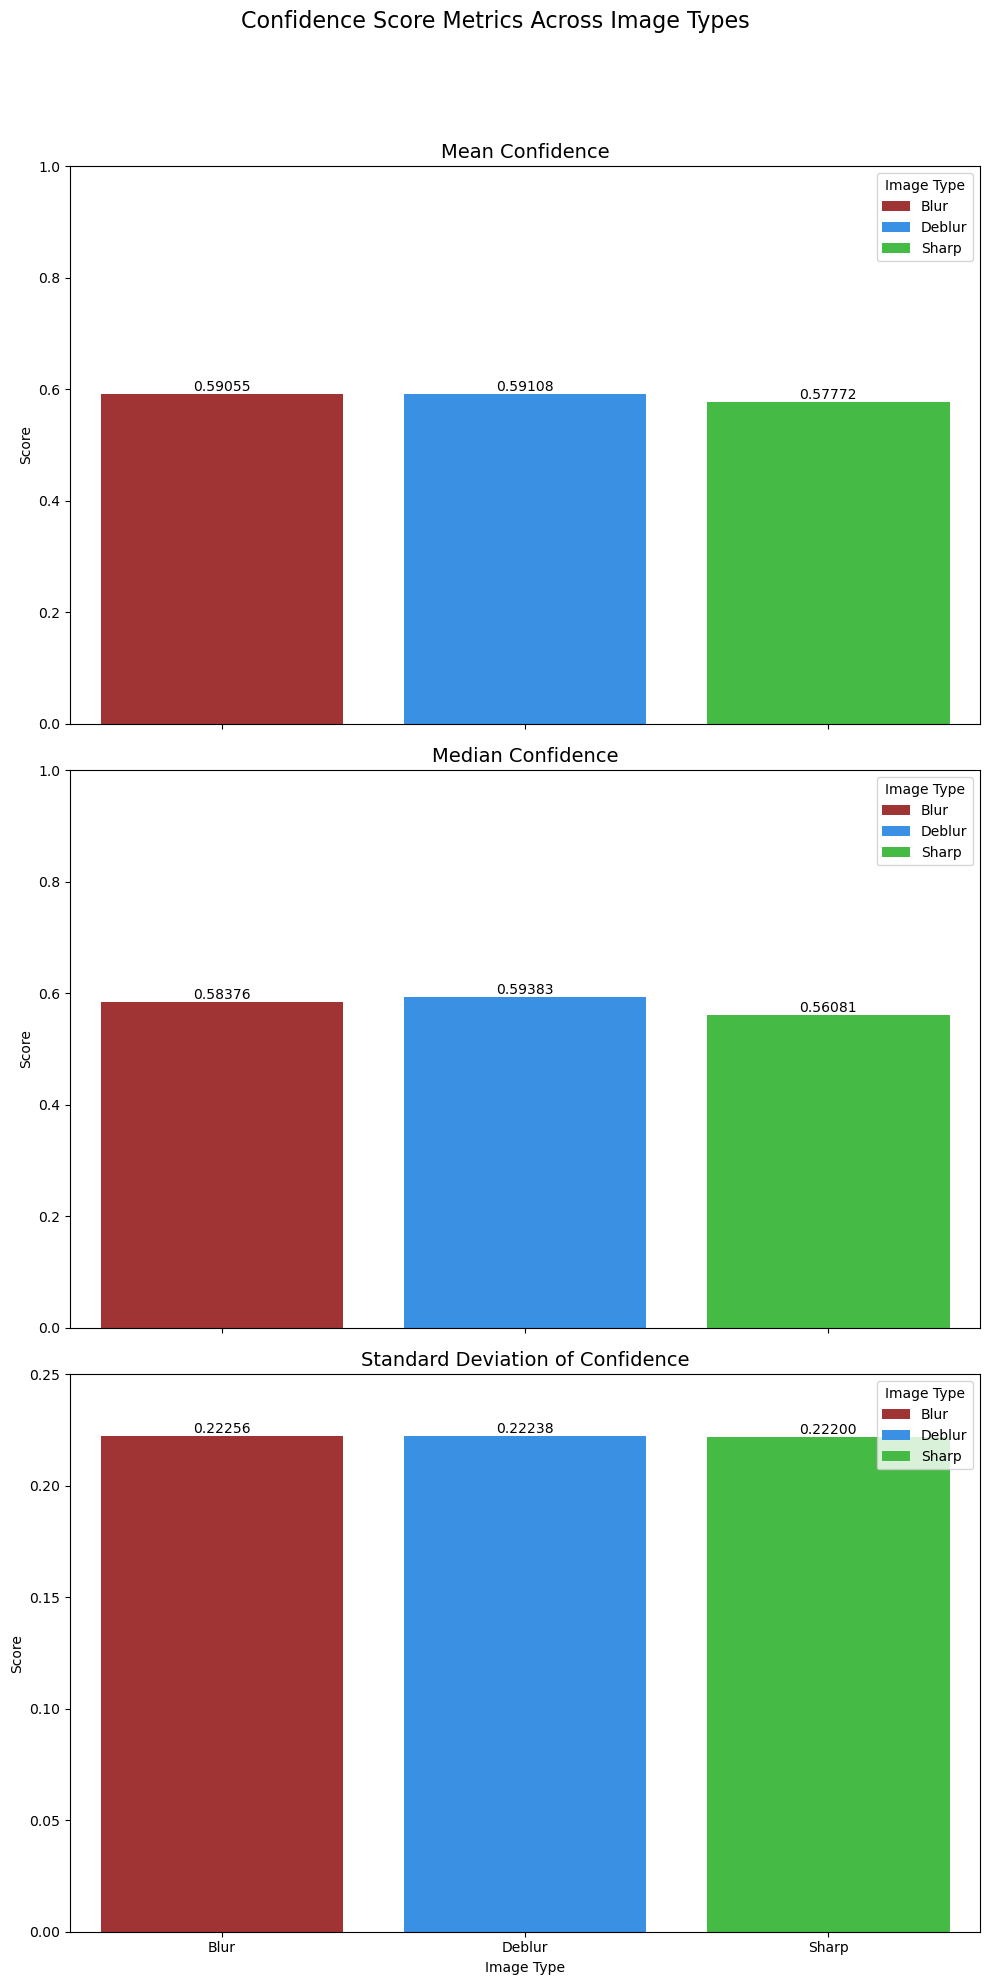

In [32]:
# visualisation
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20), sharex=True)
fig.suptitle('Confidence Score Metrics Across Image Types', fontsize=16, y=1.02)

palette = {'Blur': 'firebrick', 'Deblur': 'dodgerblue', 'Sharp': 'limegreen'}

# This is for mean
sns.barplot(x='Image Type', y='Value', data=df_metrics[df_metrics['Metric Type'] == 'Mean Confidence'],
            hue='Image Type', palette=palette, ax=axes[0], legend=True)
axes[0].set_title('Mean Confidence', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.5f', label_type='edge')

# this is for median
sns.barplot(x='Image Type', y='Value', data=df_metrics[df_metrics['Metric Type'] == 'Median Confidence'],
            hue='Image Type', palette=palette, ax=axes[1], legend=True)
axes[1].set_title('Median Confidence', fontsize=14)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.5f', label_type='edge')

# this is fo standard deviation
sns.barplot(x='Image Type', y='Value', data=df_metrics[df_metrics['Metric Type'] == 'Std Dev Confidence'],
            hue='Image Type', palette=palette, ax=axes[2], legend=True)
axes[2].set_title('Standard Deviation of Confidence', fontsize=14)
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 0.25) # change the limit
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.5f', label_type='edge')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 
plt.show()

Analyse The Precision, Recall, mAP50, mAP50-95, and F1-Score from The Training Model

In this part, we run the YOLO training model in evaluation mode, to get the metrics such as precision, recall, mAP50, mAP50-95, and F1 score

In [50]:
blur_yaml_path = os.path.join(base_dir,"..","data","train_test_split","blur", 'blur.yaml') # change this accordinly
sharp_yaml_path = os.path.join(base_dir,"..","data","train_test_split","sharp", 'sharp.yaml') # change this accordinly
data_yaml_path

print(blur_yaml_path)
print(data_yaml_path)
print(sharp_yaml_path)

d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\blur\blur.yaml
d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\deblur_richardson_lucy\deblur.yaml
d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\train_test_split\sharp\sharp.yaml


In [34]:
# now we can run the YOLO training model
# Run the YOLO training model on blur dataset
start_time = time.perf_counter()
metrics_blur = training_model.val(data=blur_yaml_path)

# print(metrics_blur.results_dict)
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")



Ultralytics 8.4.21  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 6.12.8 MB/s, size: 72.3 KB)
val: Scanning D:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\data\train_test_split\blur\validation\labels.cache... 750 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.0it/s 9.3s0.2s
                   all        750       5213       0.34      0.226       0.22      0.136
                person        402       1577      0.542      0.495      0.498      0.289
               bicycle         22         38      0.286     0.0526      0.113     0.0635
                   car         70        216      0.367      0.255      0.233      0.138
            motorcycle         27         74      0.457      0.122      0.179     0.0772
        

In [35]:
# processing the result
blur_precision = metrics_blur.results_dict.get('metrics/precision(B)', 0.0)
blur_recall = metrics_blur.results_dict.get('metrics/recall(B)', 0.0)
blur_map50 = metrics_blur.results_dict.get('metrics/mAP50(B)', 0.0)
blur_map5095 = metrics_blur.results_dict.get('metrics/mAP50-95(B)', 0.0)
blur_fitness = metrics_blur.results_dict.get('fitness', 0.0)
blur_preprocess = metrics_blur.speed['preprocess']
blur_inference = metrics_blur.speed['inference']
blur_loss = metrics_blur.speed['loss']
blur_postprocess = metrics_blur.speed['postprocess']

blur_f1 = 2 * (blur_precision *blur_recall) / (blur_precision + blur_recall) if (blur_precision + blur_recall) > 0 else 0.0

# add speed: {'preprocess': 1.3209079202963039, 'inference': 21.58284822013229, 'loss': 0.001560379983857274, 'postprocess': 1.5127725598635153}

# print the metrics
print("\nEvaluation Metrics for Blur Dataset:")
print(f"  Precision for Blur dataset: {blur_precision:.4f}")
print(f"  Recall for Blur dataset: {blur_recall:.4f}")
print(f"  mAP50 for Blur dataset: {blur_map50:.4f}")
print(f"  mAP50-95 for Blur dataset: {blur_map5095:.4f}")
print(f"  Fitness for Blur dataset: {blur_fitness:.4f}")
print(f"  F1 Score for Blur dataset: {blur_f1:.4f}")
print(f"  Preprocess time for Blur dataset: {blur_preprocess:.4f} millisecond") # loading time, resize, normalize, convert to tensor
print(f"  Inference time for Blur dataset: {blur_inference:.4f} millisecond") # model forward pass
print(f"  Loss calculation time for Blur dataset: {blur_loss:.4f} millisecond") # Calculate validation loss (only during eval, not production)
print(f"  Postprocess time for Blur dataset: {blur_postprocess:.4f} millisecond") # NMS (Non-Maximum Suppression), format results, scale boxes


blur_class_names = metrics_blur.names
blur_class_p = metrics_blur.box.p          # Precision per class
blur_class_r = metrics_blur.box.r          # Recall per class
blur_class_ap50 = metrics_blur.box.ap50    # mAP50 per class
blur_class_maps = metrics_blur.box.maps    # mAP50-95 per class
blur_class_f1 = metrics_blur.box.f1        # F1-score per class
blur_nt = metrics_blur.nt_per_class

# check if all class is present
class_names_list = []
gt_counts_list = []
precision_list = []
recall_list = []
ap50_list = []
ap50_95_list = []
f1_score_list = []

for class_id in sorted(blur_class_names.keys()):
    class_names_list.append(blur_class_names.get(class_id, f'Unknown_{class_id}'))

    precision_list.append(blur_class_p[class_id] if class_id < len(blur_class_p) else np.nan)
    recall_list.append(blur_class_r[class_id] if class_id < len(blur_class_r) else np.nan)
    ap50_list.append(blur_class_ap50[class_id] if class_id < len(blur_class_ap50) else np.nan)
    ap50_95_list.append(blur_class_maps[class_id] if class_id < len(blur_class_maps) else np.nan)
    f1_score_list.append(blur_class_f1[class_id] if class_id < len(blur_class_f1) else np.nan)
    gt_counts_list.append(blur_nt[class_id] if class_id < len(blur_nt) else 0)

blur_class_summary = {
    'Class': class_names_list,
    'Number of GT': gt_counts_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'AP50': ap50_list,
    'AP50-95': ap50_95_list,
    'F1-Score': f1_score_list
}

df_blur_class_summary = pd.DataFrame(blur_class_summary)
# set the pandas to forcefully display all data
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)
print(df_blur_class_summary)


Evaluation Metrics for Blur Dataset:
  Precision for Blur dataset: 0.3400
  Recall for Blur dataset: 0.2261
  mAP50 for Blur dataset: 0.2196
  mAP50-95 for Blur dataset: 0.1358
  Fitness for Blur dataset: 0.1358
  F1 Score for Blur dataset: 0.2716
  Preprocess time for Blur dataset: 0.3701 millisecond
  Inference time for Blur dataset: 5.0537 millisecond
  Loss calculation time for Blur dataset: 0.0013 millisecond
  Postprocess time for Blur dataset: 1.5967 millisecond
             Class  Number of GT  Precision    Recall      AP50   AP50-95  F1-Score
0           person          1577   0.542294  0.495244  0.497904  0.289373  0.517702
1          bicycle            38   0.286457  0.052632  0.113350  0.063508  0.088925
2              car           216   0.367379  0.254630  0.233405  0.138393  0.300785
3       motorcycle            74   0.456725  0.121622  0.178657  0.077161  0.192091
4         airplane            14   0.341067  0.500000  0.449073  0.302444  0.405517
5              bus   

In [36]:
df_blur_class_summary

,Class,Number of GT,Precision,Recall,AP50,AP50-95,F1-Score
0,person,1577,0.542294,0.495244,0.497904,0.289373,0.517702
1,bicycle,38,0.286457,0.052632,0.113350,0.063508,0.088925
2,car,216,0.367379,0.254630,0.233405,0.138393,0.300785
3,motorcycle,74,0.456725,0.121622,0.178657,0.077161,0.192091
4,airplane,14,0.341067,0.500000,0.449073,0.302444,0.405517
5,bus,40,0.696817,0.450000,0.462058,0.370477,0.546849
6,train,37,0.620755,0.729730,0.703012,0.505573,0.670846
7,truck,50,0.235281,0.180000,0.108972,0.044173,0.203961
8,boat,85,0.280855,0.064475,0.077227,0.043075,0.104874
9,traffic light,109,0.396739,0.146789,0.148638,0.056867,0.214292


In [39]:
data_yaml_path

'd:\\MSC AIML - Adelaide\\!-COURSES-!\\7- COMPUTER VISION AND MULTIMODAL ML\\Assignment\\Assignment 1\\notebooks\\..\\data\\train_test_split\\deblur_richardson_lucy\\deblur2.yaml'

In [40]:
# Run the YOLO model on deblur dataset
start_time = time.perf_counter()
metrics_deblur = training_model.val(data=data_yaml_path) # this is the yaml for deblur dataset

# print(metrics_blur.results_dict)
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")



Ultralytics 8.4.21  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 3.21.2 MB/s, size: 39.5 KB)
val: Scanning D:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\data\train_test_split\deblur_richardson_lucy\validation\labels.cache... 750 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 6.0it/s 7.9s0.1s
                   all        750       5213      0.372      0.223       0.22      0.135
                person        402       1577      0.623      0.474      0.502       0.29
               bicycle         22         38      0.286      0.132      0.126     0.0568
                   car         70        216      0.386      0.213      0.211      0.123
            motorcycle         27         74      0.345      0.135      0.134  

In [41]:
# processing the result
deblur_precision = metrics_deblur.results_dict.get('metrics/precision(B)', 0.0)
deblur_recall = metrics_deblur.results_dict.get('metrics/recall(B)', 0.0)
deblur_map50 = metrics_deblur.results_dict.get('metrics/mAP50(B)', 0.0)
deblur_map5095 = metrics_deblur.results_dict.get('metrics/mAP50-95(B)', 0.0)
deblur_fitness = metrics_deblur.results_dict.get('fitness', 0.0)
deblur_preprocess = metrics_deblur.speed['preprocess']
deblur_inference = metrics_deblur.speed['inference']
deblur_loss = metrics_deblur.speed['loss']
deblur_postprocess = metrics_deblur.speed['postprocess']

deblur_f1 = 2 * (deblur_precision *deblur_recall) / (deblur_precision + deblur_recall) if (deblur_precision + deblur_recall) > 0 else 0.0

# add speed: {'preprocess': 1.3209079202963039, 'inference': 21.58284822013229, 'loss': 0.001560379983857274, 'postprocess': 1.5127725598635153}

# print the metrics
print("\nEvaluation Metrics for Deblur Dataset:")
print(f"  Precision for Deblur dataset: {deblur_precision:.4f}")
print(f"  Recall for Deblur dataset: {deblur_recall:.4f}")
print(f"  mAP50 for Deblur dataset: {deblur_map50:.4f}")
print(f"  mAP50-95 for Deblur dataset: {deblur_map5095:.4f}")
print(f"  Fitness for Deblur dataset: {deblur_fitness:.4f}")
print(f"  F1 Score for Deblur dataset: {deblur_f1:.4f}")
print(f"  Preprocess time for Deblur dataset: {deblur_preprocess:.4f} millisecond") # loading time, resize, normalize, convert to tensor
print(f"  Inference time for Deblur dataset: {deblur_inference:.4f} millisecond") # model forward pass
print(f"  Loss calculation time for Deblur dataset: {deblur_loss:.4f} millisecond") # Calculate validation loss (only during eval, not production)
print(f"  Postprocess time for Deblur dataset: {deblur_postprocess:.4f} millisecond") # NMS (Non-Maximum Suppression), format results, scale boxes


deblur_class_names = metrics_deblur.names
deblur_class_p = metrics_deblur.box.p          # Precision per class
deblur_class_r = metrics_deblur.box.r          # Recall per class
deblur_class_ap50 = metrics_deblur.box.ap50    # mAP50 per class
deblur_class_maps = metrics_deblur.box.maps    # mAP50-95 per class
deblur_class_f1 = metrics_deblur.box.f1        # F1-score per class
deblur_nt = metrics_deblur.nt_per_class

# check if all class is present
class_names_list = []
gt_counts_list = []
precision_list = []
recall_list = []
ap50_list = []
ap50_95_list = []
f1_score_list = []

for class_id in sorted(deblur_class_names.keys()):
    class_names_list.append(deblur_class_names.get(class_id, f'Unknown_{class_id}'))

    precision_list.append(deblur_class_p[class_id] if class_id < len(deblur_class_p) else np.nan)
    recall_list.append(deblur_class_r[class_id] if class_id < len(deblur_class_r) else np.nan)
    ap50_list.append(deblur_class_ap50[class_id] if class_id < len(deblur_class_ap50) else np.nan)
    ap50_95_list.append(deblur_class_maps[class_id] if class_id < len(deblur_class_maps) else np.nan)
    f1_score_list.append(deblur_class_f1[class_id] if class_id < len(deblur_class_f1) else np.nan)
    gt_counts_list.append(deblur_nt[class_id] if class_id < len(deblur_nt) else 0)

deblur_class_summary = {
    'Class': class_names_list,
    'Number of GT': gt_counts_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'AP50': ap50_list,
    'AP50-95': ap50_95_list,
    'F1-Score': f1_score_list
}

df_deblur_class_summary = pd.DataFrame(deblur_class_summary)
# set the pandas to forcefully display all data
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)
print(df_deblur_class_summary)


Evaluation Metrics for Deblur Dataset:
  Precision for Deblur dataset: 0.3721
  Recall for Deblur dataset: 0.2231
  mAP50 for Deblur dataset: 0.2196
  mAP50-95 for Deblur dataset: 0.1351
  Fitness for Deblur dataset: 0.1351
  F1 Score for Deblur dataset: 0.2790
  Preprocess time for Deblur dataset: 0.3904 millisecond
  Inference time for Deblur dataset: 3.6351 millisecond
  Loss calculation time for Deblur dataset: 0.0012 millisecond
  Postprocess time for Deblur dataset: 1.5553 millisecond
             Class  Number of GT  Precision    Recall      AP50   AP50-95  F1-Score
0           person          1577   0.623041  0.473684  0.501845  0.290061  0.538192
1          bicycle            38   0.285771  0.131579  0.126265  0.056795  0.180191
2              car           216   0.386167  0.212963  0.211369  0.122746  0.274529
3       motorcycle            74   0.344706  0.135135  0.133843  0.055563  0.194156
4         airplane            14   0.393464  0.428571  0.393596  0.243222  0.410268

'd:\\MSC AIML - Adelaide\\!-COURSES-!\\7- COMPUTER VISION AND MULTIMODAL ML\\Assignment\\Assignment 1\\notebooks\\..\\data\\train_test_split\\sharp\\sharp2.yaml'

In [43]:
# Run the YOLO model on sharp dataset
start_time = time.perf_counter()
metrics_sharp = training_model.val(data=sharp_yaml_path)

# print(metrics_blur.results_dict)
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")



Ultralytics 8.4.21  Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 9.03.1 MB/s, size: 117.1 KB)
val: Scanning D:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\data\train_test_split\sharp\validation\labels.cache... 750 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.7it/s 8.3s0.1s
                   all        750       5213      0.371      0.262      0.244      0.154
                person        402       1577      0.575      0.545      0.553      0.333
               bicycle         22         38      0.303      0.184      0.155     0.0824
                   car         70        216        0.5      0.283      0.299      0.163
            motorcycle         27         74      0.387      0.243      0.228     0.0827
      

In [44]:
# processing the result
sharp_precision = metrics_sharp.results_dict.get('metrics/precision(B)', 0.0)
sharp_recall = metrics_sharp.results_dict.get('metrics/recall(B)', 0.0)
sharp_map50 = metrics_sharp.results_dict.get('metrics/mAP50(B)', 0.0)
sharp_map5095 = metrics_sharp.results_dict.get('metrics/mAP50-95(B)', 0.0)
sharp_fitness = metrics_sharp.results_dict.get('fitness', 0.0)
sharp_preprocess = metrics_sharp.speed['preprocess']
sharp_inference = metrics_sharp.speed['inference']
sharp_loss = metrics_sharp.speed['loss']
sharp_postprocess = metrics_sharp.speed['postprocess']

sharp_f1 = 2 * (sharp_precision *sharp_recall) / (sharp_precision + sharp_recall) if (sharp_precision + sharp_recall) > 0 else 0.0

# add speed: {'preprocess': 1.3209079202963039, 'inference': 21.58284822013229, 'loss': 0.001560379983857274, 'postprocess': 1.5127725598635153}

# print the metrics
print("\nEvaluation Metrics for Sharp Dataset:")
print(f"  Precision for Sharp dataset: {sharp_precision:.4f}")
print(f"  Recall for Sharp dataset: {sharp_recall:.4f}")
print(f"  mAP50 for Sharp dataset: {sharp_map50:.4f}")
print(f"  mAP50-95 for Sharp dataset: {sharp_map5095:.4f}")
print(f"  Fitness for Sharp dataset: {sharp_fitness:.4f}")
print(f"  F1 Score for Sharp dataset: {sharp_f1:.4f}")
print(f"  Preprocess time for Sharp dataset: {sharp_preprocess:.4f} millisecond") # loading time, resize, normalize, convert to tensor
print(f"  Inference time for Sharp dataset: {sharp_inference:.4f} millisecond") # model forward pass
print(f"  Loss calculation time for Sharp dataset: {sharp_loss:.4f} millisecond") # Calculate validation loss (only during eval, not production)
print(f"  Postprocess time for Sharp dataset: {sharp_postprocess:.4f} millisecond") # NMS (Non-Maximum Suppression), format results, scale boxes


sharp_class_names = metrics_sharp.names
sharp_class_p = metrics_sharp.box.p          # Precision per class
sharp_class_r = metrics_sharp.box.r          # Recall per class
sharp_class_ap50 = metrics_sharp.box.ap50    # mAP50 per class
sharp_class_maps = metrics_sharp.box.maps    # mAP50-95 per class
sharp_class_f1 = metrics_sharp.box.f1        # F1-score per class
sharp_nt = metrics_sharp.nt_per_class

# check if all class is present
class_names_list = []
gt_counts_list = []
precision_list = []
recall_list = []
ap50_list = []
ap50_95_list = []
f1_score_list = []

for class_id in sorted(sharp_class_names.keys()):
    class_names_list.append(sharp_class_names.get(class_id, f'Unknown_{class_id}'))

    precision_list.append(sharp_class_p[class_id] if class_id < len(sharp_class_p) else np.nan)
    recall_list.append(sharp_class_r[class_id] if class_id < len(sharp_class_r) else np.nan)
    ap50_list.append(sharp_class_ap50[class_id] if class_id < len(sharp_class_ap50) else np.nan)
    ap50_95_list.append(sharp_class_maps[class_id] if class_id < len(sharp_class_maps) else np.nan)
    f1_score_list.append(sharp_class_f1[class_id] if class_id < len(sharp_class_f1) else np.nan)
    gt_counts_list.append(sharp_nt[class_id] if class_id < len(sharp_nt) else 0)

sharp_class_summary = {
    'Class': class_names_list,
    'Number of GT': gt_counts_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'AP50': ap50_list,
    'AP50-95': ap50_95_list,
    'F1-Score': f1_score_list
}

df_sharp_class_summary = pd.DataFrame(sharp_class_summary)
# set the pandas to forcefully display all data
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)
print(df_sharp_class_summary)


Evaluation Metrics for Sharp Dataset:
  Precision for Sharp dataset: 0.3708
  Recall for Sharp dataset: 0.2618
  mAP50 for Sharp dataset: 0.2444
  mAP50-95 for Sharp dataset: 0.1537
  Fitness for Sharp dataset: 0.1537
  F1 Score for Sharp dataset: 0.3069
  Preprocess time for Sharp dataset: 0.3657 millisecond
  Inference time for Sharp dataset: 3.7840 millisecond
  Loss calculation time for Sharp dataset: 0.0011 millisecond
  Postprocess time for Sharp dataset: 1.5839 millisecond
             Class  Number of GT  Precision    Recall      AP50   AP50-95  F1-Score
0           person          1577   0.574588  0.544718  0.553334  0.333138  0.559255
1          bicycle            38   0.302834  0.184211  0.154817  0.082398  0.229076
2              car           216   0.500301  0.282750  0.298810  0.163206  0.361305
3       motorcycle            74   0.386531  0.243243  0.227575  0.082669  0.298587
4         airplane            14   0.403931  0.428571  0.334002  0.206205  0.415887
5         

C:\Users\qunto\AppData\Local\Temp\ipykernel_14432\470844514.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1500x1000 with 0 Axes>

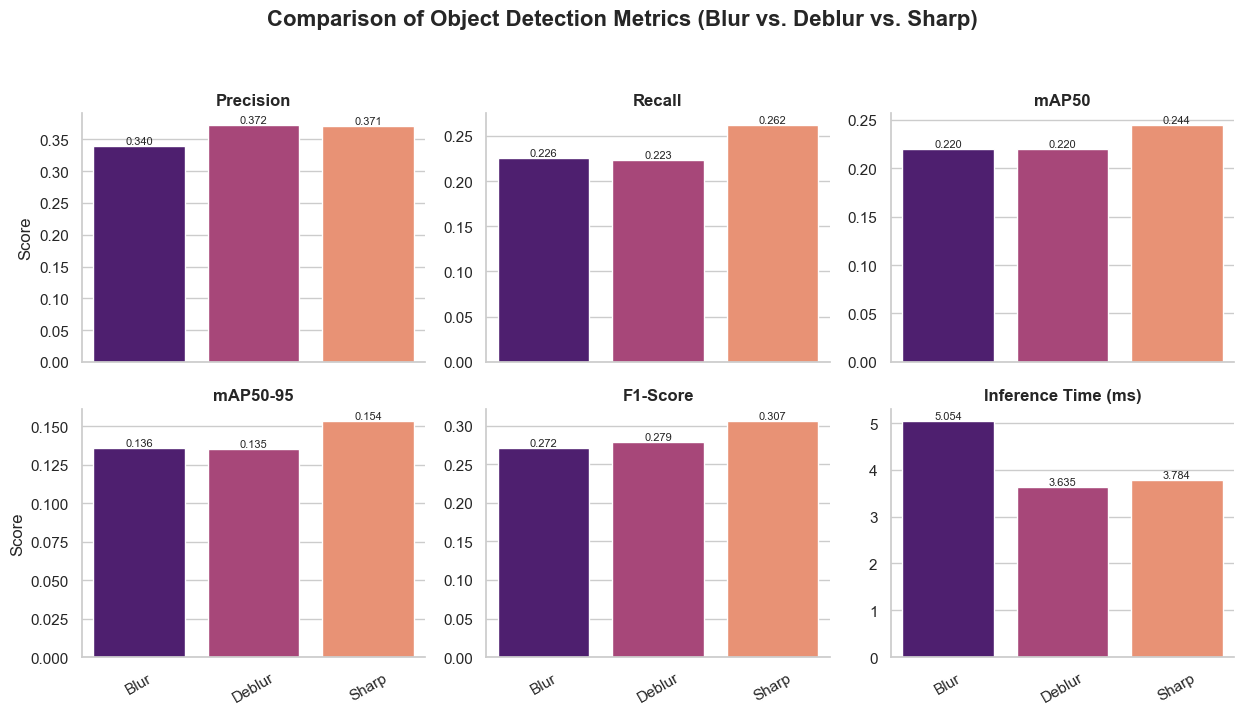

In [45]:
# visualisation for average of all classes

metrics_data_all = {
    'Metric': ['Precision', 'Recall', 'mAP50', 'mAP50-95', 'F1-Score', 'Inference Time (ms)'],
    'Blur': [blur_precision, blur_recall, blur_map50, blur_map5095, blur_f1, blur_inference],
    'Deblur': [deblur_precision, deblur_recall, deblur_map50, deblur_map5095, deblur_f1, deblur_inference],
    'Sharp': [sharp_precision, sharp_recall, sharp_map50, sharp_map5095, sharp_f1, sharp_inference]
}

df_metrics_comparison = pd.DataFrame(metrics_data_all)

# Melt the DataFrame for Seaborn bar plot
df_melted = df_metrics_comparison.melt(id_vars='Metric', var_name='Image Type', value_name='Score') # melt te datarame for seaborn plot

plt.figure(figsize=(15, 10))
sns.set_theme(style="whitegrid") # set the theme

g = sns.catplot(
    data=df_melted,
    x='Image Type',
    y='Score',
    col='Metric',
    kind='bar',
    col_wrap=3, # Wrap columns after 3 plots
    height=3.5, # Height of each facet
    aspect=1.2, # Aspect ratio of each facet
    palette='magma',
    sharey=False # Allow each plot to have its own y-axis scale
)

# Adjust titles and add value labels
for ax in g.axes.flat:
    metric_name = ax.get_title().split(' = ')[1]
    ax.set_title(f'{metric_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('') # Remove x-label from individual plots
    ax.tick_params(axis='x', rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=8)

plt.suptitle('Comparison of Object Detection Metrics (Blur vs. Deblur vs. Sharp)', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

In [46]:
# Now, we want to get the metrics of top 8 classes and visualise the metrics
# get the most GT
combined_gt = pd.concat([df_blur_class_summary[['Class', 'Number of GT']], df_deblur_class_summary[['Class', 'Number of GT']], df_sharp_class_summary[['Class', 'Number of GT']]])
overall_gt = combined_gt.groupby('Class')['Number of GT'].sum().reset_index() # group the class and the number of GT
top_8_gt = overall_gt.nlargest(8, 'Number of GT')
print(top_8_gt)


            Class  Number of GT
49         person          4731
22          chair           705
18            car           648
12           book           459
26            cup           453
72  traffic light           327
13         bottle           300
27   dining table           291


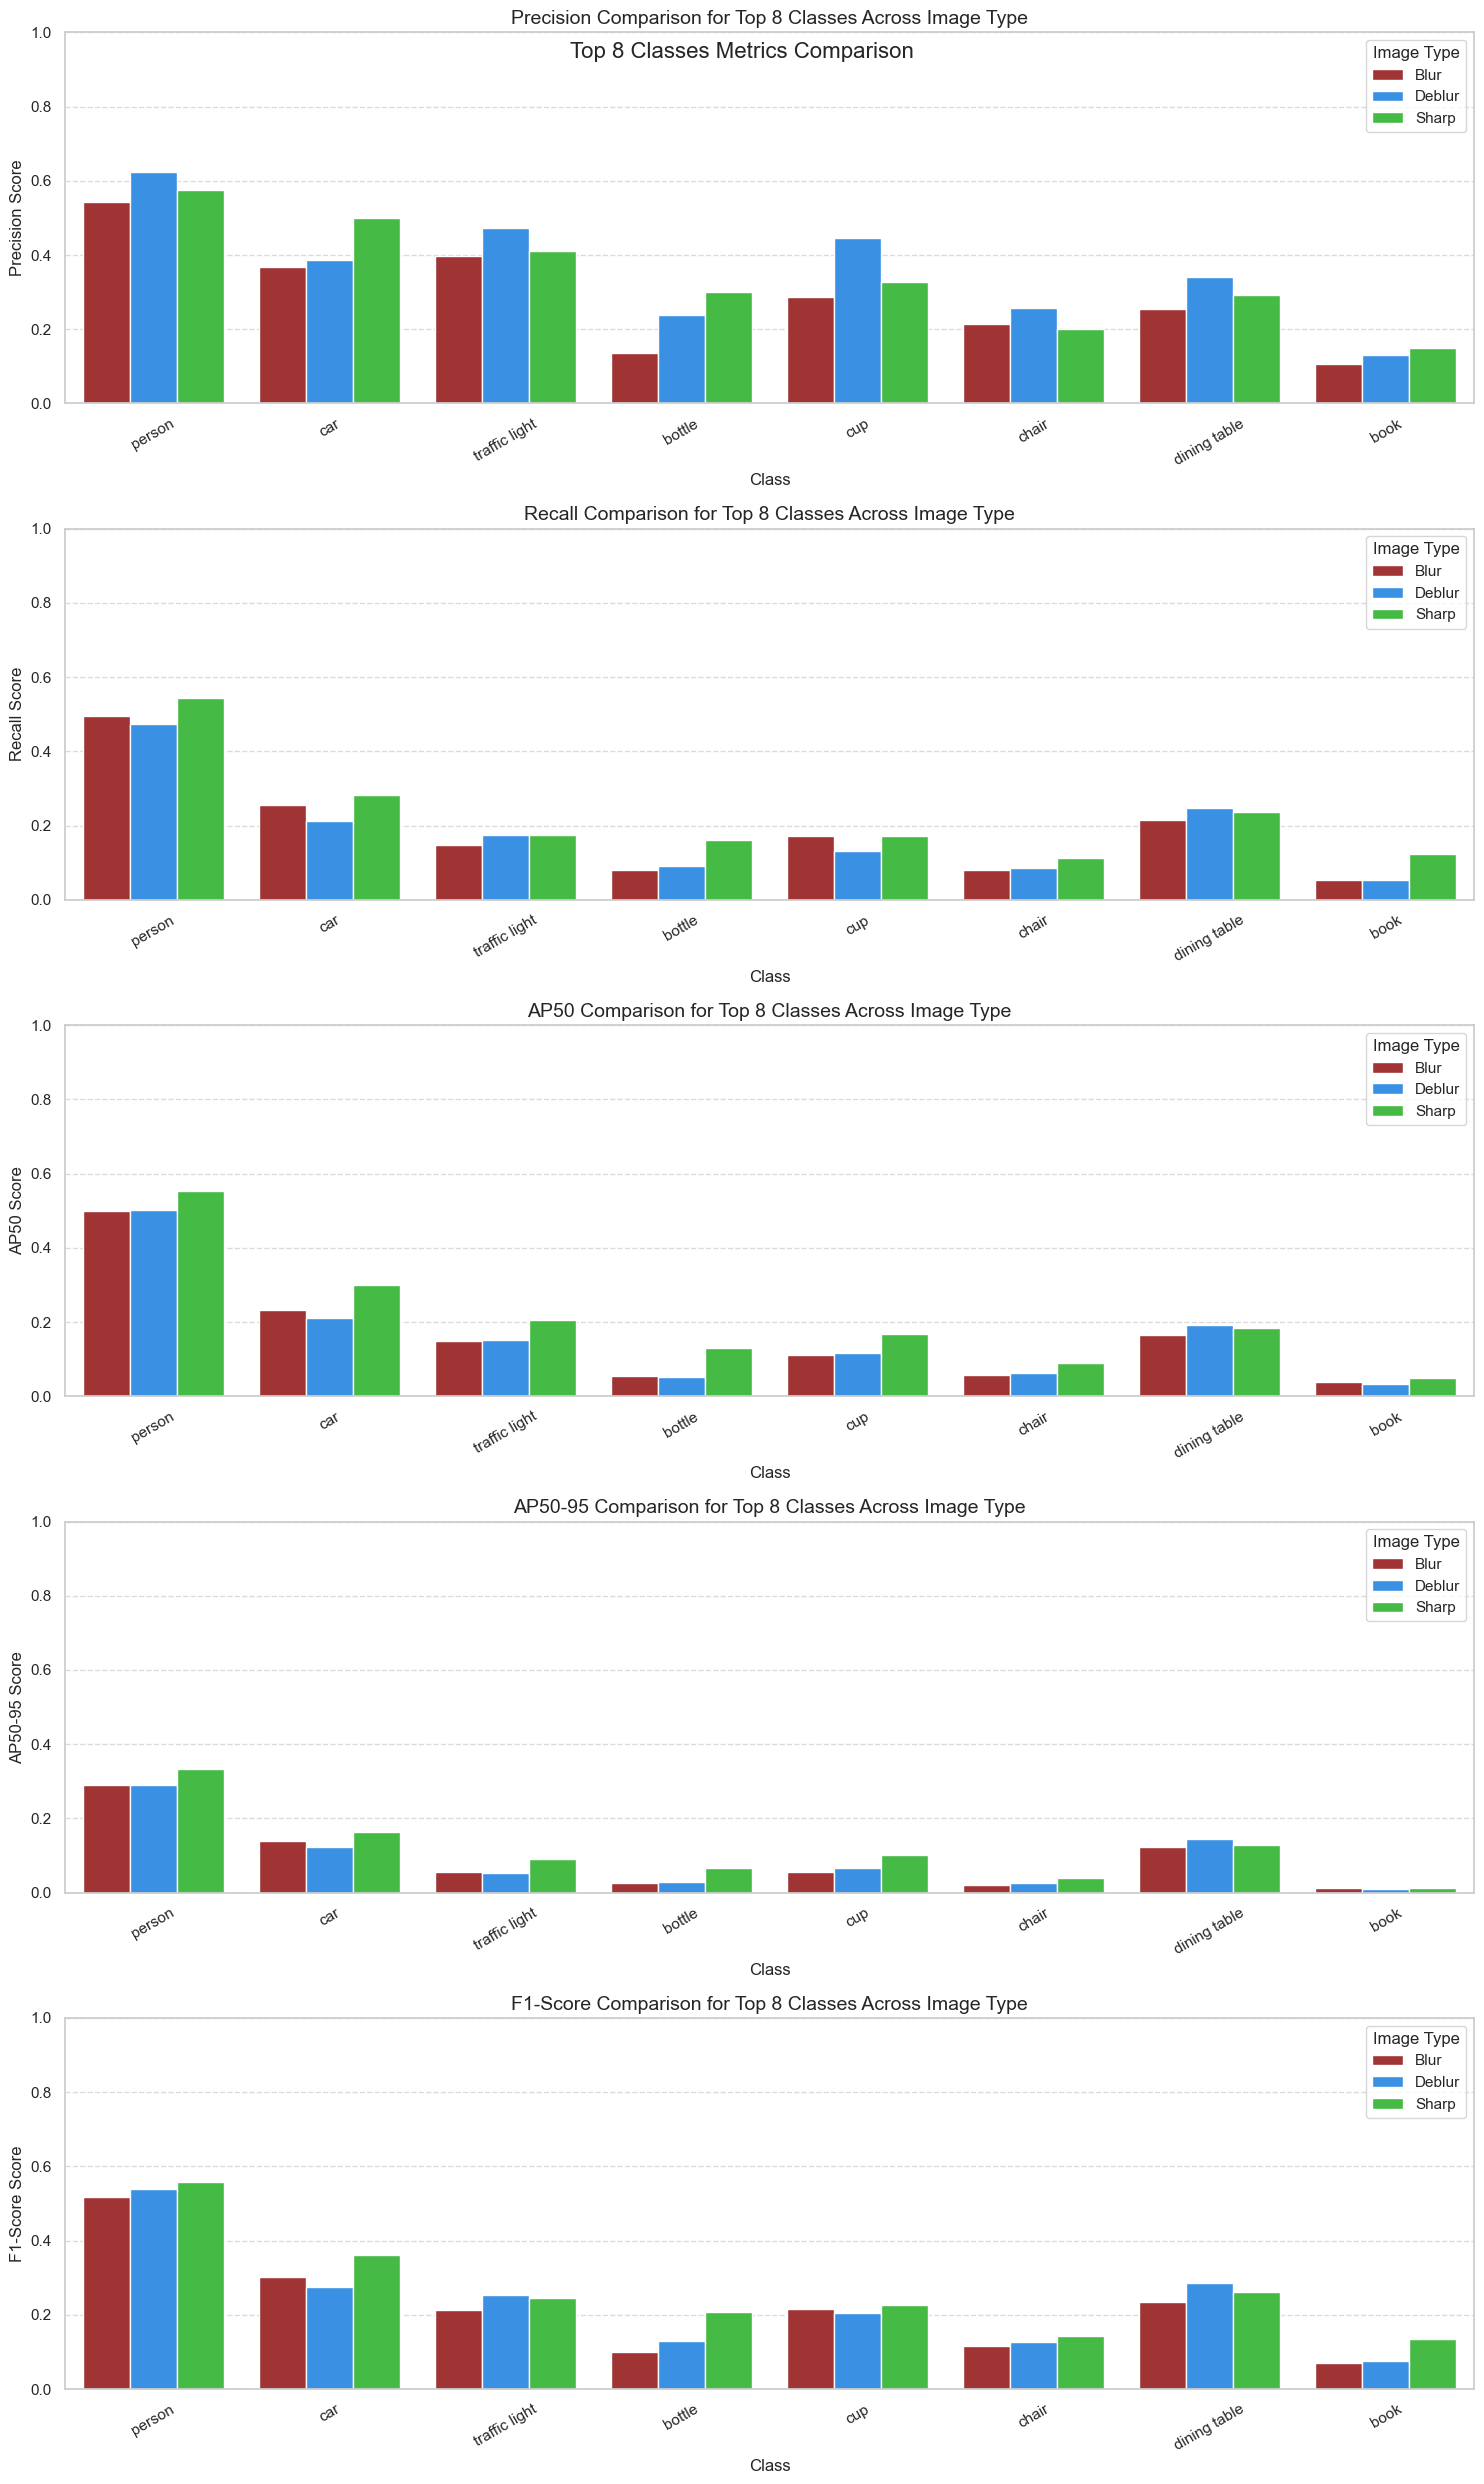

In [47]:
# now, we want to visualise it. We use subplot 5 rows for each metrics, 1 column

metrics = ['Precision', 'Recall', 'AP50', 'AP50-95', 'F1-Score'] # define the metrics
top_8_class_names = top_8_gt['Class'].tolist()

# get each dataframe
df_blur_top8 = df_blur_class_summary[df_blur_class_summary['Class'].isin(top_8_class_names)].copy()
df_deblur_top8 = df_deblur_class_summary[df_deblur_class_summary['Class'].isin(top_8_class_names)].copy()
df_sharp_top8 = df_sharp_class_summary[df_sharp_class_summary['Class'].isin(top_8_class_names)].copy()

df_blur_top8['Image Type'] = 'Blur' # assign the image type
df_deblur_top8['Image Type'] = 'Deblur' # assign the image type
df_sharp_top8['Image Type'] = 'Sharp' # assign the image type

# combining all metrics
combined_top8 = pd.concat([df_blur_top8[['Class', 'Image Type'] + metrics], df_deblur_top8[['Class', 'Image Type'] + metrics], df_sharp_top8[['Class', 'Image Type'] + metrics]])

# we transform the data for easier plotting with seaborn
df_melted_metrics = combined_top8.melt(id_vars=['Class', 'Image Type'], value_vars = metrics, var_name='Metrics', value_name = 'Score')

# create the subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15,25), sharex=False)

palette_colors = {'Blur': 'firebrick', 'Deblur': 'dodgerblue', 'Sharp': 'limegreen'} # define the palette colors

for i, metric in enumerate(metrics):
    ax = axes[i]
    metric_data = df_melted_metrics[df_melted_metrics['Metrics'] == metric]
    sns.barplot(data = metric_data, x = 'Class', y = 'Score', hue = 'Image Type', palette = palette_colors, ax=ax)

    ax.set_title(f"{metric} Comparison for Top 8 Classes Across Image Type", fontsize=14)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel(f"{metric} Score", fontsize=12)
    ax.set_ylim(0,1)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Top 8 Classes Metrics Comparison', fontsize=16)
plt.show()
